In [1]:
# constructive_tanh.py
from __future__ import annotations
import math
from typing import Optional, Tuple

import jax
import jax.numpy as jnp
import numpy as np
from flax import nnx

import matplotlib.pyplot as plt

# --- Always run in float64 for your machine-precision studies
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

In [2]:
def cheb_vandermonde(x: jnp.ndarray, K: int) -> jnp.ndarray:
    """A[j,k] = T_k(x_j) for k=0..K via T_{k+1}=2 x T_k - T_{k-1}."""
    x = x.astype(DTYPE)
    n = x.shape[0]
    A = jnp.zeros((n, K + 1), dtype=DTYPE)
    if K >= 0: A = A.at[:, 0].set(1.0)
    if K >= 1: A = A.at[:, 1].set(x)
    if K >= 2:
        def body(carry, k):
            Tkm1, Tk = carry                  # each (n,)
            Tkp1 = 2.0 * x * Tk - Tkm1
            return (Tk, Tkp1), Tkp1
        (_, _), seq = jax.lax.scan(body, (A[:,0], A[:,1]), jnp.arange(1, K))
        A = A.at[:, 2:].set(seq.T)
    return A



def de_la_vallee_poussin_window(K: int, m: int) -> jnp.ndarray:
    """
    Window weights w_k reproducing the de la Vallée Poussin operator in 1D.
    w_k = 1 for 0<=k<=m ; w_k = 2 - k/m for m<k<=2m ; else 0.
    """
    k = jnp.arange(K + 1)
    w = jnp.where(k <= m, 1.0, jnp.where(k <= 2 * m, 2.0 - k / m, 0.0))
    return w.astype(DTYPE)

def cheb_coeffs_from_samples(x: jnp.ndarray, y: jnp.ndarray, K: int,
                             solver: str = "svd",
                             rcond: float | None = None,
                             tikhonov: float = 0.0) -> jnp.ndarray:
    """
    Solve A c ≈ y for Chebyshev coefficients c_k, k=0..K.
    - 'svd': highest accuracy; truncates tiny singular values via rcond
             or applies Tikhonov if tikhonov>0
    - 'qr' : faster, still stable, but less robust than SVD
    """
    x = x.astype(DTYPE); y = y.astype(DTYPE)
    A = cheb_vandermonde(x, K)                      # (N, K+1)
    N = x.shape[0]
    if N < (K + 1):
        raise ValueError(f"Underdetermined: need at least {K+1} samples, got {N}.")

    # Column scaling (improves conditioning)
    col_norms = jnp.maximum(jnp.linalg.norm(A, axis=0), DTYPE(1e-300))
    A_s = A / col_norms

    if solver == "svd":
        U, S, Vh = jnp.linalg.svd(A_s, full_matrices=False)
        if rcond is None:
            # conservative FP64 cutoff; adjust if you know your noise level
            rcond = jnp.finfo(DTYPE).eps * max(A_s.shape)
        if tikhonov > 0.0:
            # Tikhonov: (S / (S^2 + λ)) U^T y
            Sinv = S / (S * S + DTYPE(tikhonov))
        else:
            # Truncated pseudoinverse
            Sinv = jnp.where(S > S[0] * DTYPE(rcond), 1.0 / S, 0.0)
        c_scaled = (Vh.T * Sinv) @ (U.T @ y)
        c = c_scaled / col_norms
        return c

    elif solver == "qr":
        Q, R = jnp.linalg.qr(A_s, mode="reduced")
        c_scaled = jnp.linalg.solve(R, Q.T @ y)
        c = c_scaled / col_norms
        return c

    else:
        raise ValueError("solver must be 'svd' or 'qr'")

def V_from_samples(x: jnp.ndarray, y: jnp.ndarray, m: int) -> jnp.ndarray:
    """
    Build V_k(f) for k=0..2m by:
      - projecting onto Chebyshev basis (least-squares) to get c_k
      - applying the de la Vallée Poussin window
    """
    K = 2 * m
    print(x.shape, y.shape)
    c = cheb_coeffs_from_samples(x, y, K)
    w = de_la_vallee_poussin_window(K, m)
    V = w * c
    return V  # (K+1,)



In [3]:

# -----------------------------
# Utilities: finite differences in weight-space
# -----------------------------
def binom_table(K: int) -> jnp.ndarray:
    """Lower-triangular binomial coefficients B[p,r]=C(p,r), 0<=r<=p<=K."""
    B = np.zeros((K + 1, K + 1), dtype=np.float64)
    for p in range(K + 1):
        B[p, 0] = 1.0
        B[p, p] = 1.0
        for r in range(1, p):
            B[p, r] = B[p - 1, r - 1] + B[p - 1, r]
    return jnp.asarray(B, dtype=DTYPE)


def sign_table(K: int) -> jnp.ndarray:
    ip = jnp.arange(K + 1, dtype=jnp.int32)[:, None]
    ir = jnp.arange(K + 1, dtype=jnp.int32)[None, :]
    parity = (ip - ir) & 1
    S = jnp.where(parity == 0, 1.0, -1.0)
    return jnp.tril(S).astype(DTYPE)

def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    """C[k,p] s.t. T_k(x) = sum_{p=0}^k C[k,p] x^p."""
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk    = C[k]
        Tkm1  = C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]       # multiply by x and scale 2
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)



In [4]:
# --- Analytic bias: choose transcendental t in (0,1), b = arctanh(t)
def analytic_bias_for_tanh(choice: str = "pi") -> tuple[float, float]:
    # Returns (b, t) with t = tanh(b)
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)   # transcendental
    elif choice == "e":
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)  # transcendental
    else:
        raise ValueError("choice must be 'pi' or 'e'")
    b = jnp.arctanh(t)
    return float(b), float(t)

# --- Evaluate all derivatives tanh^{(n)}(b) via derivative polynomials P_n(t)
def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    """
    Compute d^n/dx^n tanh(x) at a point x with tanh(x)=t, for n=0..K.
    Uses P_{n+1}(y)=(1-y^2) P'_n(y) in coefficient space + Horner eval.
    No autodiff; O(K^2). Returns array [P_0(t), P_1(t), ..., P_K(t)].
    """
    t = jnp.asarray(t, dtype=DTYPE)
    # Max degree of P_K is K+1 -> allocate K+2 coeffs [c0 + c1 y + ... + c_{K+1} y^{K+1}]
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE)
    coeff = coeff.at[1].set(1.0)           # P_0(y) = y
    derivs = jnp.zeros(K + 1, dtype=DTYPE)
    derivs = derivs.at[0].set(t)           # P_0(t) = t

    def poly_derivative(c):
        # c: length L; returns length L with trailing zeros
        idx = jnp.arange(1, L, dtype=DTYPE)
        dc = jnp.zeros_like(c)
        dc = dc.at[:-1].set(idx * c[1:])
        return dc

    def mul_by_1_minus_y2(c):
        # (1 - y^2) * c : shift-and-subtract
        out = jnp.zeros_like(c)
        out = out.at[:].add(c)             # * 1
        out = out.at[2:].add(-c[:-2])      # - y^2 * c
        return out

    def poly_eval(c, t):
        # Horner over full length (extra zeros are fine)
        def body(j, acc):  # iterate from high to low
            return acc * t + c[j]
        return jax.lax.fori_loop(0, L, lambda j, acc: body(L - 1 - j, acc), DTYPE(0.0))

    def step(n, carry):
        coeff, derivs = carry
        dc = poly_derivative(coeff)        # P'_n
        coeff_next = mul_by_1_minus_y2(dc) # P_{n+1}
        val = poly_eval(coeff_next, t)     # P_{n+1}(t)
        derivs = derivs.at[n + 1].set(val)
        return (coeff_next, derivs)

    coeff, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs  # tanh^{(n)}(b) for n=0..K, with P_0(t)=t


In [5]:

# -----------------------------
# The fixed-dictionary NNX module
# -----------------------------
class ConstructiveTanh1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with phi = tanh, as per Mhaskar.
    Inputs: x in [-1,1] (shape [...,])
    Output: scalar approximation N(x).
    All arrays are float64 and non-trainable; the only data-dependence is V (outer weights).
    """

    def __init__(self, m: int, V: jnp.ndarray, b: Optional[float] = None):
        self.m = int(m)
        self.K = int(2 * m)
        #GAMMA = DTYPE(jnp.e * jnp.pi / 4.0)  # ≈ 2.136
        GAMMA = DTYPE(1.0)

        self.h = DTYPE(GAMMA / self.m)
        print(f"m={self.m}, K={self.K}, h={self.h}")
        # pick bias with nonvanishing derivatives up to order K
        print(f"Choosing bias b for K={self.K}...")
        
        if b is None:
            b, t = analytic_bias_for_tanh("pi")  # deterministic
            self.b = DTYPE(b)
            self.t = DTYPE(t)
        else:
            self.b = DTYPE(b)
            self.t = jnp.tanh(self.b)

        # Precompute fixed tables
        print("Precomputing tables...")
        print(f"Binomial table B (size {(self.K+1, self.K+1)}):")
        self.B = binom_table(self.K)         # binomial C(p,r)
        print(f"Sign table S (size {(self.K+1, self.K+1)}):")
        self.Sgn = sign_table(self.K)        # (-1)^(p-r)
        print(f"Chebyshev monomial coeffs C (size {(self.K+1, self.K+1)}):")
        self.C = cheb_monomial_coeffs(self.K)  # C[k,p] coefficients of T_k in monomial basis
        print(f"Hyperbolic tangent derivatives (size {(self.K+1,)}):")
        self.deriv = tanh_derivatives_at_b_poly(self.K, self.t)

        assert jnp.all(jnp.isfinite(self.deriv)), "Non-finite tanh derivatives."

        # Data-dependent outer coefficients (windowed Chebyshev projection)
        if V.shape != (self.K + 1,):
            raise ValueError(f"V must have shape ({self.K+1},), got {V.shape}")
        self.V = V.astype(DTYPE)

        # Precompute normalizers for Ψ_p
        print("Precomputing normalizers...")
        p = jnp.arange(self.K + 1, dtype=DTYPE)
        self.norm = (self.h ** p) * self.deriv  # shape (K+1,)
        print(f"The normalizers (size {(self.K+1,)}): {self.norm}, with self.h={self.h} and self.deriv={self.deriv}")

        inv_norm = 1.0 / self.norm  # after (B)
        print(f" Inv norm shape: {inv_norm.shape}, values: {inv_norm}")
        inv_norm = (1.0 / self.norm).reshape(-1, 1)

        self.S = self.Sgn * self.B
        self.M = self.C @ (self.S * inv_norm)  # (K+1,K+1)

        # Guard + row scaling (preserves N(x) because V is linear on rows)
        row_scale = jnp.maximum(jnp.max(jnp.abs(self.M), axis=1, keepdims=True), DTYPE(1.0))
        self.M = self.M / row_scale
        self.V = self.V * row_scale.squeeze(-1)

        assert jnp.all(jnp.isfinite(self.M)), "Non-finite M (try smaller GAMMA or smaller m)."
        assert jnp.all(jnp.isfinite(self.V)), "Non-finite V (projection blew up)."

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """
        Evaluate N(x) for x with shape [...], x in [-1,1].
        Implementation:
          Φ_r(x) = tanh((r h) x + b), r=0..K
          G_k(x) = sum_r M[k,r] * Φ_r(x)
          N(x)   = sum_k V_k * G_k(x)
        """
        x = jnp.asarray(x, dtype=DTYPE)

        # Broadcast to batch: compute Φ(x) with shape [..., K+1]
        r = DTYPE(jnp.arange(self.K + 1))  # (K+1,)
        # (..., 1) * (K+1,) -> (..., K+1)
        Phi = jnp.tanh(jnp.expand_dims(x, -1) * (r * self.h) + self.b)

        # G(x) = Phi @ M^T  -> (..., K+1)
        G = Phi @ self.M.T

        # N(x) = G @ V  -> (...)
        y = G @ self.V
        return y

In [6]:

# -----------------------------
# High-level constructor
# -----------------------------
def build_constructive_tanh_from_samples(
    x_samples: jnp.ndarray,
    y_samples: jnp.ndarray,
    m: int,
    b: Optional[float] = None,
) -> ConstructiveTanh1D:
    """
    Given samples (x_i, y_i) with x_i in [-1,1], build the Mhaskar-style network N(x).
    """
    print(f"Building linear functional V")
    V = V_from_samples(x_samples, y_samples, m)  # (2m+1,)

    print(f"Building ConstructiveTanh1D with m={m}, b={b}")
    model = ConstructiveTanh1D(m=m, V=V, b=b)
    return model

In [7]:

# -----------------------------
# Convenience: sin(2π k x) demo
# -----------------------------
def cheb_nodes_second_kind(N: int) -> jnp.ndarray:
    """x_j = cos((j+0.5)π/N), j=0..N-1."""
    j = jnp.arange(N, dtype=DTYPE)
    return jnp.cos((j + 0.5) * jnp.pi / N)


def build_for_sine(k_freq: int, m: int, N_samples: Optional[int] = None) -> Tuple[ConstructiveTanh1D, jnp.ndarray, jnp.ndarray]:
    """
    Convenience wrapper: sample f(x)=sin(2π k x) on Chebyshev nodes and build N(x).
    Returns (model, x_nodes, y_nodes).
    """
    K = 2 * m
    N = N_samples if N_samples is not None else max(2 * K + 5, K + 1)  # a bit oversampled
    print(f"Using N={N} samples for m={m} (K={K})")
    print(f"Chebyshev nodes in [-1,1]: {N} samples")
    x = cheb_nodes_second_kind(N)  # in [-1,1]
    print(f"Sampled Chebyshev nodes x in [-1,1]: {x}")
    y = jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
    print(f"Sampled sin(2π*{k_freq}*x) at Chebyshev nodes x in [-1,1]: {y}")
    print(f"Building model...")
    model = build_constructive_tanh_from_samples(x, y, m)
    return model, x, y



In [8]:

# -----------------------------
# Example usage
# -----------------------------
k = 1
m = 6  # controls dictionary size; neurons ~ (2m+1)  # or None to auto-choose
model, x_nodes, y_nodes = build_for_sine(k, m)


Using N=29 samples for m=6 (K=12)
Chebyshev nodes in [-1,1]: 29 samples
Sampled Chebyshev nodes x in [-1,1]: [ 9.98533414e-01  9.86826523e-01  9.63549993e-01  9.28976720e-01
  8.83512044e-01  8.27688998e-01  7.62162055e-01  6.87699459e-01
  6.05174215e-01  5.15553857e-01  4.19889102e-01  3.19301530e-01
  2.14970440e-01  1.08119018e-01  6.12323400e-17 -1.08119018e-01
 -2.14970440e-01 -3.19301530e-01 -4.19889102e-01 -5.15553857e-01
 -6.05174215e-01 -6.87699459e-01 -7.62162055e-01 -8.27688998e-01
 -8.83512044e-01 -9.28976720e-01 -9.63549993e-01 -9.86826523e-01
 -9.98533414e-01]
Sampled sin(2π*1*x) at Chebyshev nodes x in [-1,1]: [-9.21470213e-03 -8.26769198e-02 -2.27025316e-01 -4.31588000e-01
 -6.68295726e-01 -8.83209336e-01 -9.97081684e-01 -9.24358400e-01
 -6.13771611e-01 -9.75722795e-02  4.82364164e-01  9.06686915e-01
  9.75876229e-01  6.28273331e-01  3.84734139e-16 -6.28273331e-01
 -9.75876229e-01 -9.06686915e-01 -4.82364164e-01  9.75722795e-02
  6.13771611e-01  9.24358400e-01  9.97081

In [9]:

# Evaluate on a dense grid and print max error
xs = jnp.linspace(-1.0, 1.0, 1001, dtype=DTYPE)
ys_true = jnp.sin(2.0 * jnp.pi * DTYPE(k) * xs)
ys_pred = model(xs)
err = jnp.max(jnp.abs(ys_pred - ys_true))
print(f"(k={k}, m={m}) max |N(x)-f(x)| on 1001-pt grid: {err:.3e}")



(k=1, m=6) max |N(x)-f(x)| on 1001-pt grid: 2.617e+02


In [10]:
r  = jnp.arange(model.K + 1, dtype=DTYPE)
Phi = jnp.tanh(xs[:, None] * (r * model.h) + model.b)
# Chebyshev polynomial via two paths should match:
T = cheb_vandermonde(xs, model.K)            # now T_k(2x)
P_direct = T @ model.V
G = Phi @ model.M.T
P_via_G  = G @ model.V

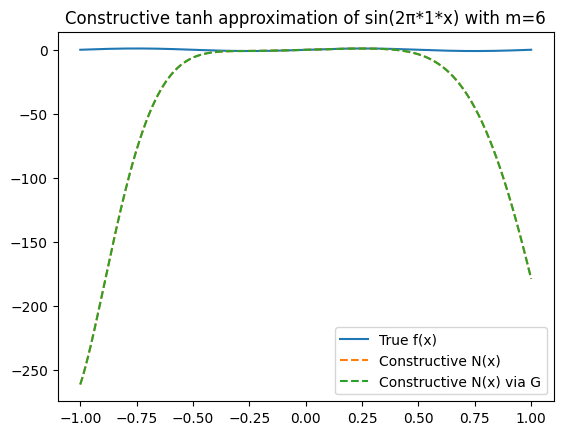

In [11]:
plt.plot(xs, ys_true, label='True f(x)')
plt.plot(xs, ys_pred, '--', label='Constructive N(x)')
plt.plot(xs, P_via_G, '--', label='Constructive N(x) via G')
plt.title(f"Constructive tanh approximation of sin(2π*{k}*x) with m={m}")
plt.legend()
plt.show()

In [12]:
# Monomial reproduction via finite diffs:
xs = jnp.linspace(-1.0, 1.0, 201, dtype=DTYPE)
r  = jnp.arange(model.K + 1, dtype=DTYPE)
Phi = jnp.tanh(xs[:, None] * (r * model.h) + model.b)
S_rowscaled = model.S * (1.0 / model.norm).reshape(-1,1)
Psi = Phi @ S_rowscaled.T  # columns ≈ x^p
print("max |Ψ_0 - 1|", float(jnp.max(jnp.abs(Psi[:,0] - 1))))
print("max |Ψ_1 - x|", float(jnp.max(jnp.abs(Psi[:,1] - xs))))

# Chebyshev polynomial via two paths should match:
T = cheb_vandermonde(xs, model.K)            # now T_k(2x)
P_direct = T @ model.V
G = Phi @ model.M.T
P_via_G  = G @ model.V
print("max |P_direct - P_via_G|", float(jnp.max(jnp.abs(P_direct - P_via_G))))

# Final target error:
f_true = jnp.sin(2.0 * jnp.pi * DTYPE(k) * xs)
print("poly approx error   :", float(jnp.max(jnp.abs(P_direct - f_true))))
print("network total error :", float(jnp.max(jnp.abs(P_via_G - f_true))))

max |Ψ_0 - 1| 0.0
max |Ψ_1 - x| 0.0068758395675933
max |P_direct - P_via_G| 2.0513905450245384e+71
poly approx error   : 2.0513905450245386e+71
network total error : 7.238894023091461e+55


ValueError: x and y must have same first dimension, but have shapes (201,) and (1001,)

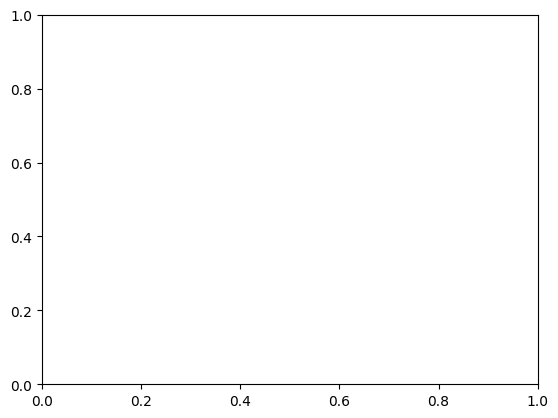

In [13]:
plt.plot(xs, ys_true, label='True f(x)')
plt.plot(xs, P_via_G, '--', label='Constructive N(x)')
plt.title(f"Constructive tanh approximation of sin(2π*{k}*x) with m={m}")
plt.legend()
plt.show()